# HSI Biopsy Data Analysis Example

This notebook demonstrates basic loading and analysis of hyperspectral imaging data from biopsy samples.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys

# Add project root to path
sys.path.append('..')

# Import project modules
from src.dataset.biopsy2_dataset import Biopsy2Dataset
from src.constants import ALL_PATIENT_IDS
import h5py
import torch 
import torch.nn.functional as F
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
from matplotlib import colormaps

Loaded 52 patient IDs from metadata CSV


## Data Loading

In this section, we'll load the HSI data using the Biopsy2Dataset class where each sample represents a single HSI cube.

In [ ]:
# Initialize the dataset
biopsy_dataset = Biopsy2Dataset(use_preprocessed=True)

for i in biopsy_dataset.cube_samples:
    print(i)

# Get total number of HSI cubes in the dataset
print(f"Total HSI cubes in dataset: {len(biopsy_dataset)}")

{'id': '1.10_1', 'patient_id': 'S1.10', 'fov': '1', 'file_path': '/home/macht/thesis/hsi-biopsy/data/biopsy_preprocessed/HyperProbe1.1_Biopsy_S1.10_FOV1.npy', 'metadata': {'id': 'S.1.10', 'age': 76.0, 'sex': 'M', 'type_of_tumor': 'Mening', 'grading': '1', 'additional_info': 'meningioma parasagittale fronto-parietale bilaterale\n', 'histology': 'Meningioma transizionale, grado 1', 'Ki-67-index': '8-10%', 'normalized_id': 'S1.10'}}
{'id': '1.10_2', 'patient_id': 'S1.10', 'fov': '2', 'file_path': '/home/macht/thesis/hsi-biopsy/data/biopsy_preprocessed/HyperProbe1.1_Biopsy_S1.10_FOV2.npy', 'metadata': {'id': 'S.1.10', 'age': 76.0, 'sex': 'M', 'type_of_tumor': 'Mening', 'grading': '1', 'additional_info': 'meningioma parasagittale fronto-parietale bilaterale\n', 'histology': 'Meningioma transizionale, grado 1', 'Ki-67-index': '8-10%', 'normalized_id': 'S1.10'}}
{'id': '1.11_1', 'patient_id': 'S1.11', 'fov': '1', 'file_path': '/home/macht/thesis/hsi-biopsy/data/biopsy_preprocessed/HyperProbe1

In [ ]:
# Get a single HSI cube by index
sample = biopsy_dataset.get_sample_by_id('1.18_1')
print(f"\nSample ID: {sample['id']}")
print(f"Patient ID: {sample['patient_id']}")
print(f"FOV: {sample['fov']}")

# Print shape of the HSI cube
print(f"HSI cube shape: {sample['hsi_cube'].shape}")

# Print metadata
print("\nMetadata:")
for key, value in sample['metadata'].items():
    print(f"  {key}: {value}")


Sample ID: 1.18_1
Patient ID: S1.18
FOV: 1
HSI cube shape: (127, 2048, 2048)

Metadata:
  id: S.1.18
  age: 55.0
  sex: F
  type_of_tumor: Mening
  grading: 1.0
  additional_info: mening clinoideo/planum dx 
  histology: Meningioma meningoteliale, grado 1 (WHO CNS 2021). 
  Ki-67-index: 0.04
  normalized_id: S1.18


## Visualization

Let's visualize the data by creating an RGB representation and looking at some spectral signatures.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-60.2..464.0].
/home/home/tim_ivan/thesis/tim_thesis/notebooks/../src/visualize_data.py:39: UserWarning: You passed a edgecolor/edgecolors ([]) for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  scatter_plot = ax_img.scatter([], [], c=[], s=100, marker="+", edgecolors=[])


Button(description='Clear Selection', style=ButtonStyle())

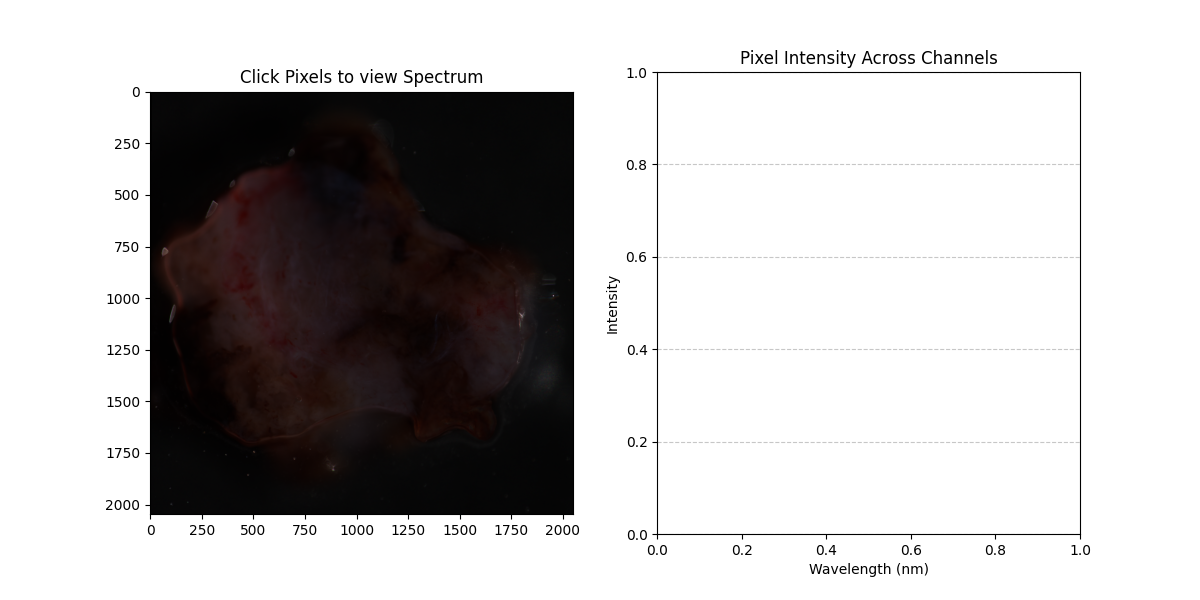

In [4]:
from src.visualize_data import show_interactive_image_with_spectrum

%matplotlib widget
show_interactive_image_with_spectrum(sample['hsi_cube'])

## Displaying Patient Samples with Metadata

The function `display_with_metadata` allows us to view all HSI samples for a specific patient alongside their metadata.

In [ ]:
from src.visualize_data import display_with_metadata

# Get a patient ID from the first sample or use a specific one

patient_id = ALL_PATIENT_IDS.S1_2
# Display all samples for this patient with their metadata
display_with_metadata(biopsy_dataset, patient_id)

## Store Pre-Processed Samples

In [ ]:
path = '/home/macht/thesis/hsi-biopsy/data/biopsy_preprocessed'
from tqdm import tqdm
# Ensure the output directory exists
os.makedirs(path, exist_ok=True)

def fix_problematic_pixels(hsi_cube):
    """Replace NaN and infinite values with 0.001"""
    # Create a mask for NaN and infinite values
    mask = np.isnan(hsi_cube) | np.isinf(hsi_cube)
    # Replace problematic values with 0.001
    if np.any(mask):
        hsi_cube[mask] = 0.001
    return hsi_cube

for sample in biopsy_dataset.cube_samples:
    # Get the original .mat filename
    print(f"Processing {sample['file_path']}")
    original_filename = os.path.basename(sample['file_path'])
    npy_filename = os.path.splitext(original_filename)[0] + '.npy'
    npy_path = os.path.join(path, npy_filename)
    if os.path.exists(npy_path):
        print(f"File {npy_path} already exists, skipping.")
        continue
    with h5py.File(sample['file_path'], 'r') as f:
        hsi_cube = np.array(f['Ref_hyper'])

    if hsi_cube.shape[0] != 127:
        print(f"Warning: Expected 127 channels, found {hsi_cube.shape[0]} in {sample['file_path']}.")
    orig_problem_count = np.isnan(hsi_cube).sum() + np.isinf(hsi_cube).sum()
    print(f"Original problem count: {orig_problem_count}")

    if orig_problem_count == 0:
        print("No problems in the original file, saving as is.")
        np.save(npy_path, hsi_cube)
        print(f"Saved {npy_path}")
        continue
    
    # Fix problematic pixels by setting them to 0.001
    hsi_cube = fix_problematic_pixels(hsi_cube)
    
    # Verify fix worked
    new_problem_count = np.isnan(hsi_cube).sum() + np.isinf(hsi_cube).sum()
    print(f"New problem count: {new_problem_count}")
    np.save(npy_path, hsi_cube)
    print(f"Saved {npy_path}")


# For some reason samples of patients 1_18 and 1_8 have 128 channels instead of 127 thats why we remove the first channel
for sample in tqdm(biopsy_dataset.cube_samples):
    # if sample['patient_id'] not in ['S1.18', 'S1.8', 'S1.9']:
    #     continue
    original_filename = os.path.basename(sample['file_path'])
    npy_filename = os.path.splitext(original_filename)[0] + '.npy'
    npy_path = os.path.join(path, npy_filename)
    hsi_cube = np.load(npy_path)
    if hsi_cube.shape[0] == 128:
        print(f"Removing first channel from {sample['file_path']}")
        hsi_cube = hsi_cube[1:]
        print(f"New shape: {hsi_cube.shape}")
        np.save(npy_path, hsi_cube)
        print(f"Saved {npy_path}")

Processing /home/ezhovi/biopsy2.0/HyperProbe1.1_Biopsy_S1.10_FOV1.mat
File /home/macht/thesis/hsi-biopsy/data/biopsy_preprocessed/HyperProbe1.1_Biopsy_S1.10_FOV1.npy already exists, skipping.
Processing /home/ezhovi/biopsy2.0/HyperProbe1.1_Biopsy_S1.10_FOV2.mat
File /home/macht/thesis/hsi-biopsy/data/biopsy_preprocessed/HyperProbe1.1_Biopsy_S1.10_FOV2.npy already exists, skipping.
Processing /home/ezhovi/biopsy2.0/HyperProbe1.1_Biopsy_S1.11_FOV1.mat
File /home/macht/thesis/hsi-biopsy/data/biopsy_preprocessed/HyperProbe1.1_Biopsy_S1.11_FOV1.npy already exists, skipping.
Processing /home/ezhovi/biopsy2.0/HyperProbe1.1_Biopsy_S1.11_FOV2.mat
File /home/macht/thesis/hsi-biopsy/data/biopsy_preprocessed/HyperProbe1.1_Biopsy_S1.11_FOV2.npy already exists, skipping.
Processing /home/ezhovi/biopsy2.0/HyperProbe1.1_Biopsy_S1.11_FOV3.mat
File /home/macht/thesis/hsi-biopsy/data/biopsy_preprocessed/HyperProbe1.1_Biopsy_S1.11_FOV3.npy already exists, skipping.
Processing /home/ezhovi/biopsy2.0/HyperP

## Calculate Mean of Region of Interest of Meningioma Sample

In [ ]:
import torch
import torch.nn.functional as F

hsi_cube = biopsy_dataset.get_sample_by_id("1.4_1")["hsi_cube"]
ref_data_transposed = np.transpose(hsi_cube)
print(f"Shape of transposed data: {ref_data_transposed.shape}")
ref_data_transposed[ref_data_transposed <= 0] = 10**-3
ref_data_transposed = (
    F.avg_pool2d(
        torch.tensor(ref_data_transposed).permute(2, 0, 1).unsqueeze(0),
        kernel_size=8,
        stride=8,
    )
    .squeeze(0)
    .permute(1, 2, 0)
    .numpy()
)

print(f"{ref_data_transposed.shape=}")
roi = ref_data_transposed[150:350, 150:350, :]
print(f"{roi.shape=}")
flat_roi = roi.reshape(-1, ref_data_transposed.shape[-1])
print(f"{flat_roi.shape=}")
mean_roi = np.mean(flat_roi, axis=0)
print(f"{mean_roi.shape=}")
# np.save("../data/reference/S1_4_1_mean_roi.npy", mean_roi)

/home/home/tim_ivan/thesis/tim_thesis/notebooks/../src/dataset.py:238: RuntimeWarning: divide by zero encountered in log
  delta_A = -np.log(
/home/home/tim_ivan/thesis/tim_thesis/notebooks/../src/dataset.py:238: RuntimeWarning: invalid value encountered in log
  delta_A = -np.log(


Shape of transposed data: (2048, 2048, 127)
ref_data_transposed.shape=(256, 256, 127)
roi.shape=(106, 106, 127)
flat_roi.shape=(11236, 127)
mean_roi.shape=(127,)


### Display Mean ROI of S1.4_1

Original problem count: 0
Mean ROI shape: (127,)
Mean ROI min: 0.05804782233001541
Mean ROI max: 0.4991018084211643


Text(0, 0.5, 'Normalized Intensity')

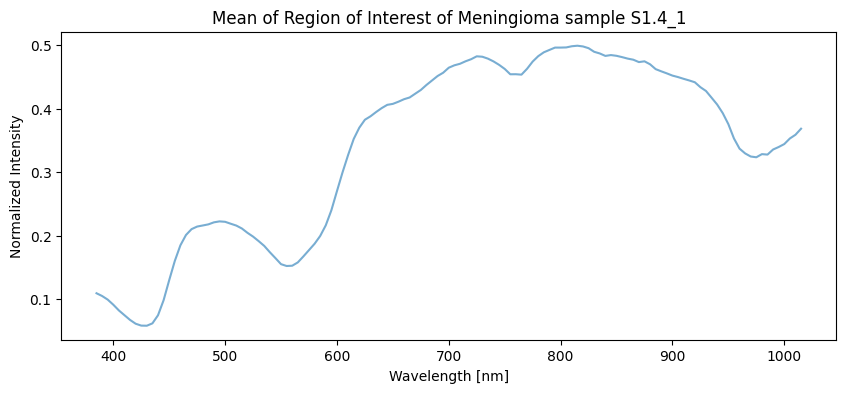

In [12]:
from src.constants import WAVELENGTHS

mean_roi = np.load("../data/reference/S1_4_1_mean_roi.npy")
orig_problem_count = np.isnan(mean_roi).sum() + np.isinf(mean_roi).sum()
print(f"Original problem count: {orig_problem_count}")
print(f"Mean ROI shape: {mean_roi.shape}")
print(f"Mean ROI min: {np.min(mean_roi)}")
print(f"Mean ROI max: {np.max(mean_roi)}")
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.set_title("Mean of Region of Interest of Meningioma sample S1.4_1")
ax.plot(WAVELENGTHS, mean_roi, alpha=0.6)
ax.set_xlabel("Wavelength [nm]")
ax.set_ylabel("Normalized Intensity")

## Calculate S1 reference Kevin

In [2]:
filename = "/mnt/Drive3/ivan/hyperprobe_biopsies/Biopsy_S1_reflectance.mat"

with h5py.File(filename, "r") as f:
    data = np.array(f["Ref_hyper"])

data_transposed = np.transpose(data)
print(f"Shape of transposed data: {data_transposed.shape}")
data_transposed[data_transposed <= 0] = 10**-3
data_transposed = F.avg_pool2d(torch.tensor(data_transposed).permute(2, 0, 1).unsqueeze(0), kernel_size=8, stride=8).squeeze(0).permute(1, 2, 0).numpy()
mean_biopsy_s1 = np.mean(data_transposed[150:350, 150:350, :].reshape(-1, data_transposed.shape[-1]), axis=0)

print(f"Mean biopsy S1 shape: {mean_biopsy_s1.shape}")

np.save("../data/reference/mean_biopsy_s1_kevin.npy", mean_biopsy_s1)

Shape of transposed data: (2048, 2048, 79)
Mean biopsy S1 shape: (79,)


## PCA Plots

100%|██████████| 80/80 [06:00<00:00,  4.50s/it]


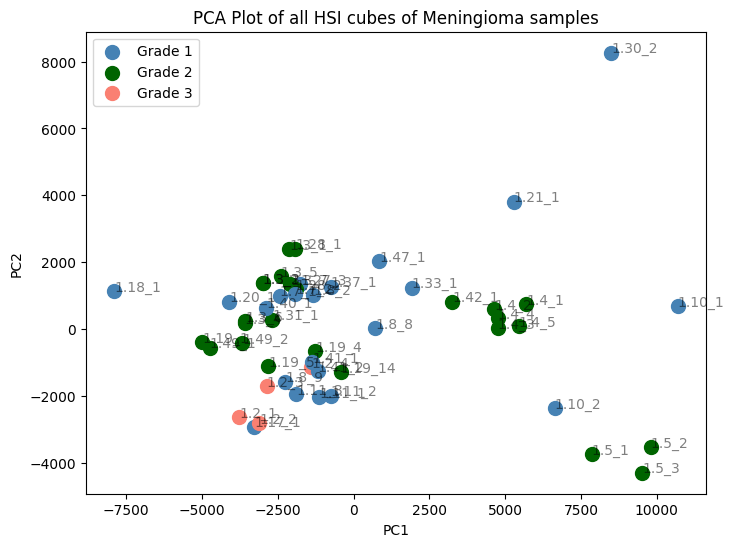

In [ ]:
# Prepare data and labels
color_map = {"1": "steelblue", "2": "darkgreen", "3": "salmon"}
unique_labels = {}
processed_patients = []
X = []
codes = []
ids = []

for sample in tqdm(biopsy_dataset.cube_samples):
    # if sample['patient_id'] in processed_patients:
    #     continue
    if sample["metadata"]["type_of_tumor"] == "Mening":
        processed_patients.append(sample["patient_id"])
        code = sample["metadata"]["grading"]
        if code not in color_map:
            print(f"Unknown grading code {code} for sample {sample['id']}")
            continue
        hsi_cube = np.load(sample["file_path"])
        hsi_cube[hsi_cube <= 0] = (
            10**-3
        )  # Replace non-positive values with a small number
        downsampled_cube = (
            F.avg_pool2d(
                torch.tensor(hsi_cube).unsqueeze(0),
                kernel_size=4,
                stride=4,
            )
            .squeeze(0)
            .numpy()
        )

        downsampled_cube = downsampled_cube.flatten()
        X.append(downsampled_cube)
        codes.append(code)
        ids.append(sample["id"])

# Convert to array
X = np.array(X)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)

# Plot PCA results
plt.figure(figsize=(8, 6))
for pc, code, id in zip(pcs, codes, ids):
    color = color_map[code]
    label = f"Grade {code}"
    if code not in unique_labels:
        unique_labels[code] = label
        plt.scatter(pc[0], pc[1], color=color, label=label, s=100)
    else:
        plt.scatter(pc[0], pc[1], color=color, s=100)
    plt.text(pc[0], pc[1], id, alpha=0.5)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Plot of all HSI cubes of Meningioma samples")
plt.legend()
plt.show()

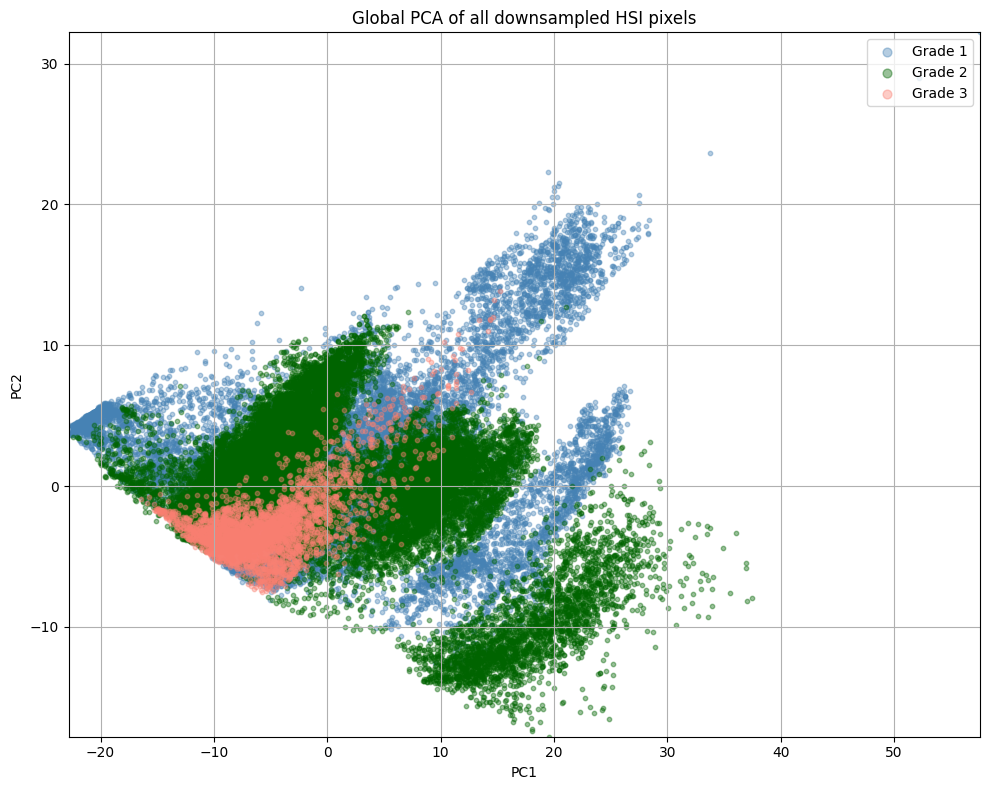

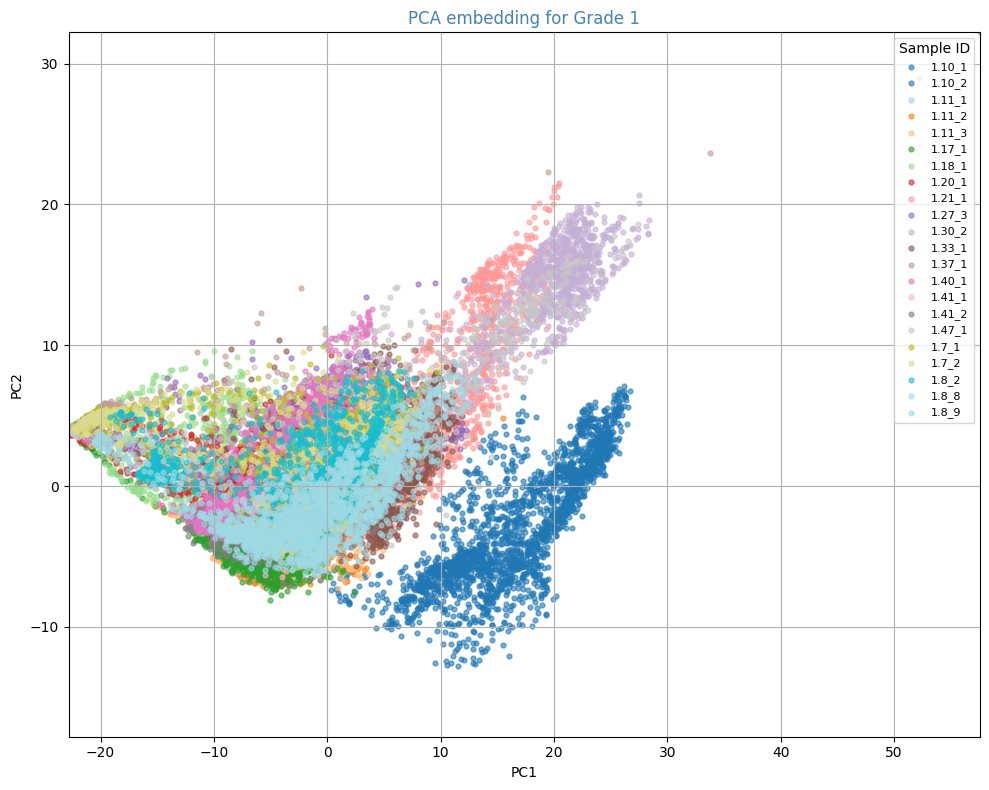

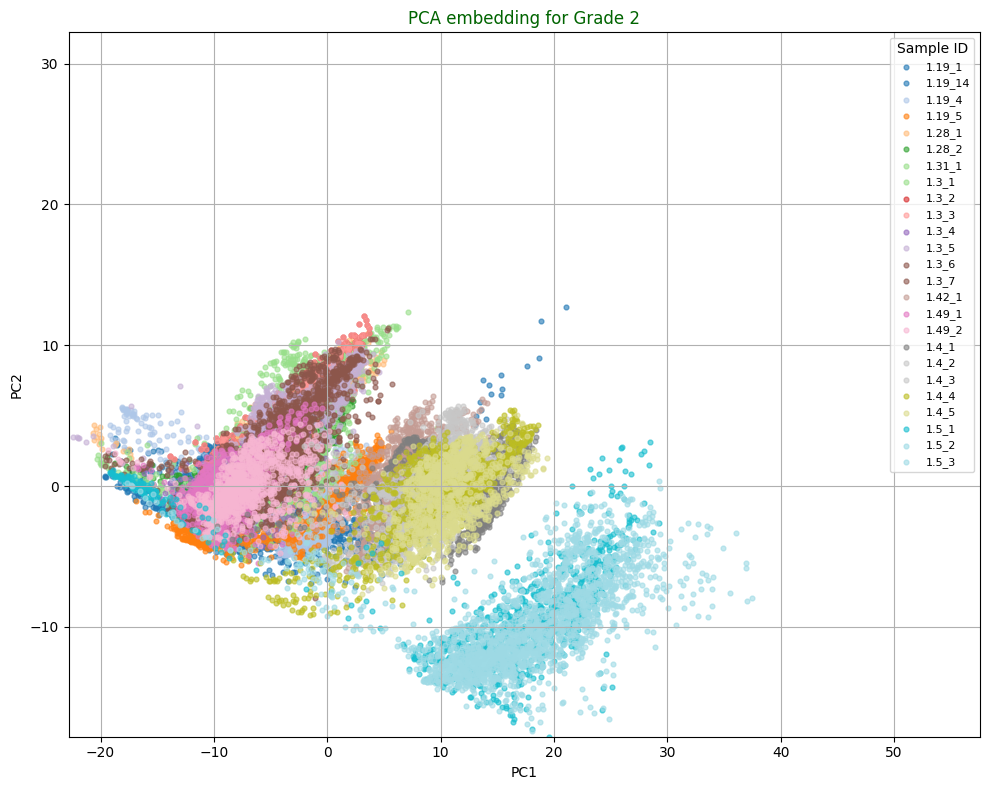

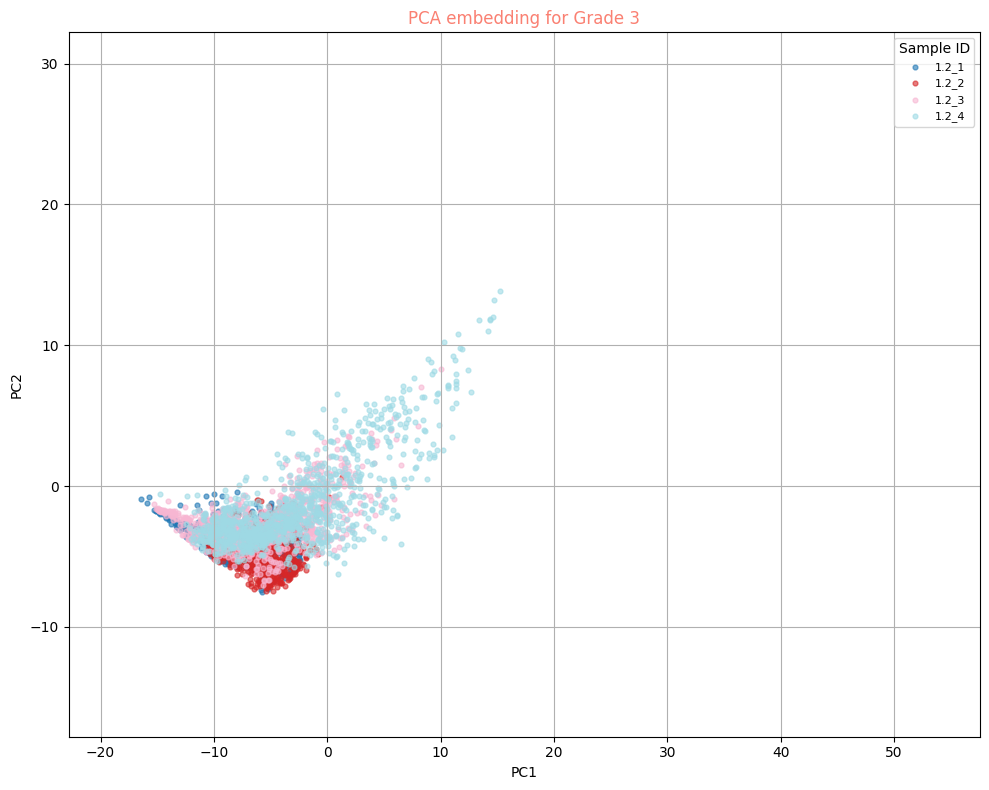

In [ ]:
# 1) Settings
grade_colors = {"1": "steelblue", "2": "darkgreen", "3": "salmon"}
grades = ["1", "2", "3"]

all_pixels  = []
all_grades  = []
all_samples = []

# 2) Load, clean & downsample
for sample in tqdm(biopsy_dataset.cube_samples, desc="Loading & downsampling"):
    if sample["metadata"]["type_of_tumor"] != "Mening":
        continue
    grade = sample["metadata"]["grading"]
    if grade not in grades:
        continue

    cube = np.load(sample["file_path"])        # (127, 2048, 2048)
    cube[cube <= 0] = 1e-3

    t    = torch.from_numpy(cube).unsqueeze(0)     # (1,127,2048,2048)
    down = F.adaptive_avg_pool2d(t, (32, 32))      # (1,127,32,32)
    down = down.squeeze(0).permute(1, 2, 0).numpy()# (32,32,127)

    pix = down.reshape(-1, 127)                    # (1024,127)
    all_pixels.append(pix)
    all_grades += [grade] * pix.shape[0]
    all_samples += [sample["id"]] * pix.shape[0]

# 3) Stack & PCA
X           = np.vstack(all_pixels)
grades_arr  = np.array(all_grades)
samples_arr = np.array(all_samples)

X_scaled = StandardScaler().fit_transform(X)
pcs      = PCA(n_components=2).fit_transform(X_scaled)

# compute shared axis limits
x_min, x_max = pcs[:,0].min(), pcs[:,0].max()
y_min, y_max = pcs[:,1].min(), pcs[:,1].max()

# 4) Global PCA plot
plt.figure(figsize=(10, 8))
for grade, color in grade_colors.items():
    mask = (grades_arr == grade)
    plt.scatter(pcs[mask, 0], pcs[mask, 1],
                s=10, c=color, alpha=0.4, label=f"Grade {grade}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Global PCA of all downsampled HSI pixels")
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.legend(loc="upper right", markerscale=2)
plt.grid(True)
plt.tight_layout()
plt.show()

# 5) Separate PCA plots per grade (same axes & same size)
cmap = colormaps["tab20"]
for grade in grades:
    mask_g = (grades_arr == grade)
    pcs_g  = pcs[mask_g]
    samps  = samples_arr[mask_g]

    unique_ids = np.unique(samps)
    n_ids = len(unique_ids)
    colors = [cmap(i / max(n_ids-1, 1)) for i in range(n_ids)]

    plt.figure(figsize=(10, 8))  # same size as global
    for i, sid in enumerate(unique_ids):
        m = (samps == sid)
        plt.scatter(pcs_g[m, 0], pcs_g[m, 1],
                    s=12, alpha=0.6, color=colors[i], label=sid)

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(f"PCA embedding for Grade {grade}", color=grade_colors[grade])
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.legend(title="Sample ID", loc="upper right", fontsize=8, title_fontsize=10)
    plt.grid(True)
    plt.tight_layout()
    plt.show()